In [ ]:
import os; os.environ['AWS_ACCESS_KEY_ID'] = 'YYY'; os.environ['AWS_SECRET_ACCESS_KEY'] = 'XXX'; os.environ['AWS_DEFAULT_REGION'] = 'us-east-1'

In [2]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import boto3

In [3]:
bildmapp = Path(r"C:\Users\daaro\OneDrive - Karlskoga Kommun\Studier\YH\AI och IoT\Kunskapskontroll 1\AI Kunskapskontroll 1 - Kod\Del 2\Bilder")

In [4]:
tillatna_format = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
# alla mina råkar vara jpg men tänkte att det kunde vara bra backup 
bildfiler = [f for f in bildmapp.iterdir() if f.suffix.lower() in tillatna_format]

print(f"Hittade {len(bildfiler)} bilder i mappen.")

Hittade 50 bilder i mappen.


In [5]:
client = boto3.client("rekognition")

In [6]:
alla_labels = []
resultat_lista = []

# Analysera bilder 
for bildfil in bildfiler:
    try:
        with open(bildfil, "rb") as f:
            image_bytes = f.read()

        response = client.detect_labels(
            Image={"Bytes": image_bytes},
            MaxLabels=10,
            MinConfidence=70
        )

        labels = response["Labels"]

        if labels:
            for label in labels:
                label_namn = label["Name"]
                confidence = label["Confidence"]

                alla_labels.append(label_namn)

                resultat_lista.append({
                    "bildnamn": bildfil.name,
                    "label": label_namn,
                    "confidence": round(confidence, 2)
                })
        else:
            resultat_lista.append({
                "bildnamn": bildfil.name,
                "label": "Inga labels hittades",
                "confidence": None
            })

    except Exception as e:
        resultat_lista.append({
            "bildnamn": bildfil.name,
            "label": f"FEL: {str(e)}",
            "confidence": None
        })

print("Bildanalysen är klar.")

Bildanalysen är klar.


In [7]:
df_resultat = pd.DataFrame(resultat_lista)

In [12]:
# Sammanställ vanligaste labels
label_counter = Counter(alla_labels)
top_10_labels = label_counter.most_common(10)

df_top10 = pd.DataFrame(top_10_labels, columns=["label", "antal"])

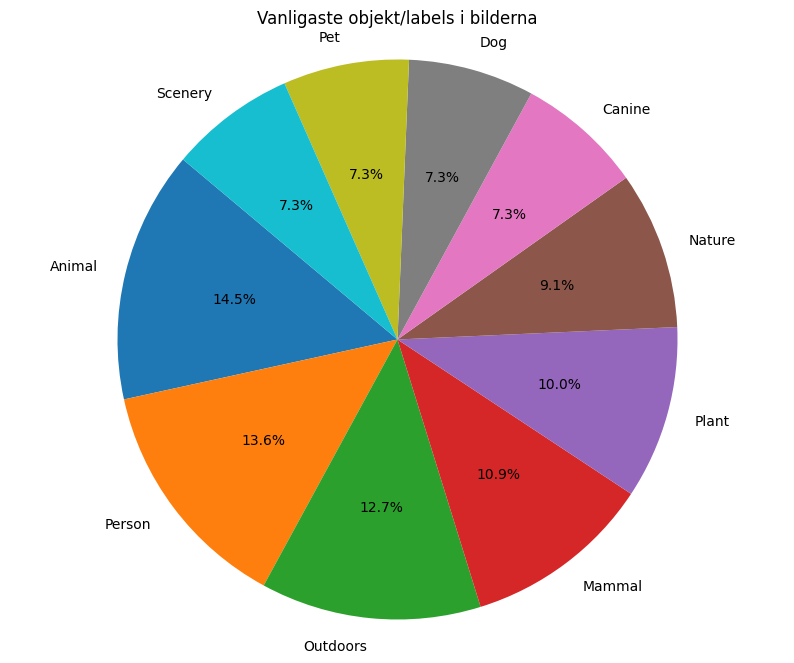

In [13]:
if len(top_10_labels) > 0:
    labels_namn = [item[0] for item in top_10_labels]
    labels_antal = [item[1] for item in top_10_labels]

    plt.figure(figsize=(10, 8))
    plt.pie(labels_antal, labels=labels_namn, autopct="%1.1f%%", startangle=140)
    plt.title("Vanligaste objekt/labels i bilderna")
    plt.axis("equal")

else:
    print("Inga labels hittades, så inget diagram kunde skapas.")

In [ ]:
# Tittar på en specifik bild, bara för att få lite mer insikt i hur den analyserar
specifik_bild = bildmapp / "bild1.jpg"  

with open(specifik_bild, "rb") as f:
    image_bytes = f.read()

response_specifik = client.detect_labels(
    Image={"Bytes": image_bytes},
    MaxLabels=10,
    MinConfidence=70
)

specifik_resultat = []
for label in response_specifik["Labels"]:
    specifik_resultat.append({
        "label": label["Name"],
        "confidence": round(label["Confidence"], 2)
    })

df_specifik = pd.DataFrame(specifik_resultat)
print(f"Resultat för bilden: {specifik_bild.name}")
display(df_specifik)

Resultat för bilden: bild1.jpg


,label,confidence
0,Road,99.48
1,Shorts,99.47
2,Female,99.20
3,Girl,99.20
4,Person,99.20
5,Teen,99.20
6,Smile,99.03
7,Urban,99.02
8,Skirt,98.99
9,Wristwatch,98.68


Kul att den är nästan lika säker på både shorts och skirt. Skorts kanske är svaret? 

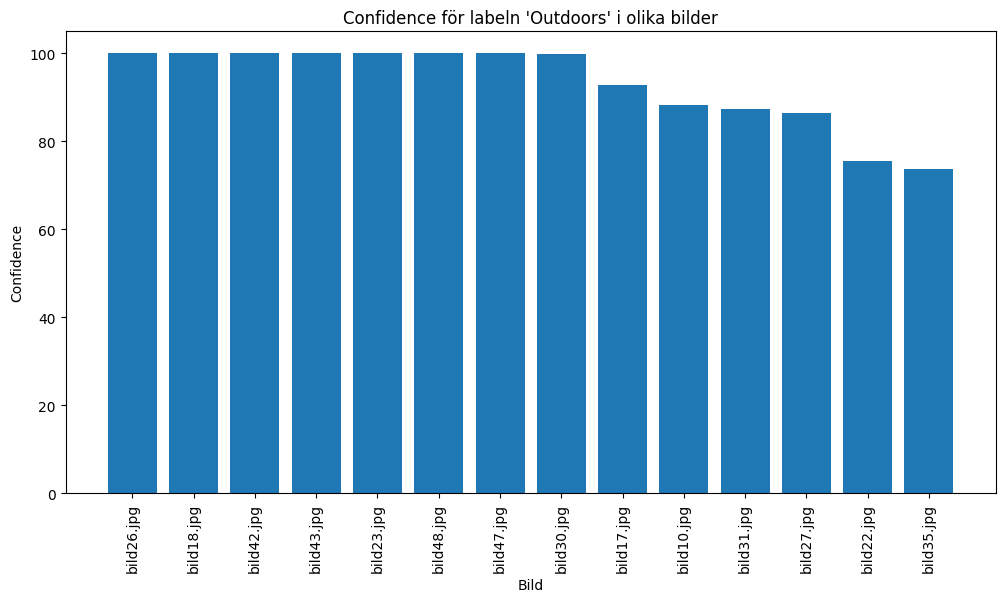

In [18]:
vald_label = "Outdoors"  

df_vald_label = df_resultat[df_resultat["label"].str.lower() == vald_label.lower()].copy()

if not df_vald_label.empty:
    df_vald_label = df_vald_label.sort_values(by="confidence", ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(df_vald_label["bildnamn"], df_vald_label["confidence"])
    plt.xticks(rotation=90)
    plt.ylabel("Confidence")
    plt.xlabel("Bild")
    plt.title(f"Confidence för labeln '{vald_label}' i olika bilder")
else:
    print(f"Ingen bild hade labeln '{vald_label}'.")